In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import re

In [2]:
cwd = os.getcwd()
cwd

'/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models'

In [3]:
def get_data(file):
    x_data = []
    y_data = []
    
    with open(file, 'r') as f:
        for line in f:
            if not line.startswith(('@', '#')):  # Skip header lines
                parts = line.strip().split()
                if len(parts) >= 2:  # Ensure there are at least two columns of data
                    try:
                        x_data.append(float(parts[0]))
                        y_data.append(float(parts[1]))
                    except ValueError:
                        # Handle cases where data might not be purely numerical
                        continue
    return np.array(x_data), np.array(y_data)

In [4]:
def summary_stats(data):  
    
    data_mean = np.mean(data)
    data_std = np.std(data)
    data_min = np.min(data)
    data_max = np.max(data)
    
    return data_mean, data_std, data_min, data_max

In [5]:
def mask(x, y, medoid_time_ps, time_tol_ps=1.0):
    # Mask out the medoid frame (by time)
    mask = np.abs(x - medoid_time_ps) > time_tol_ps
    x_filt = x[mask]
    y_filt = y[mask]

    return x_filt, y_filt

In [6]:
def moving_average(y, window, center=True):
    """
    Moving average with edge handling (uses reflection padding).
    window: number of points (will be forced odd if center=True).
    """
    y = np.asarray(y, dtype=float)

    if window < 1:
        raise ValueError("window must be >= 1")

    if center and window % 2 == 0:
        window += 1  # force odd for symmetric smoothing

    pad = window // 2 if center else 0
    if pad > 0:
        y_pad = np.pad(y, pad_width=pad, mode="reflect")
    else:
        y_pad = y

    kernel = np.ones(window, dtype=float) / window
    y_smooth = np.convolve(y_pad, kernel, mode="valid")

    return y_smooth

## Binder

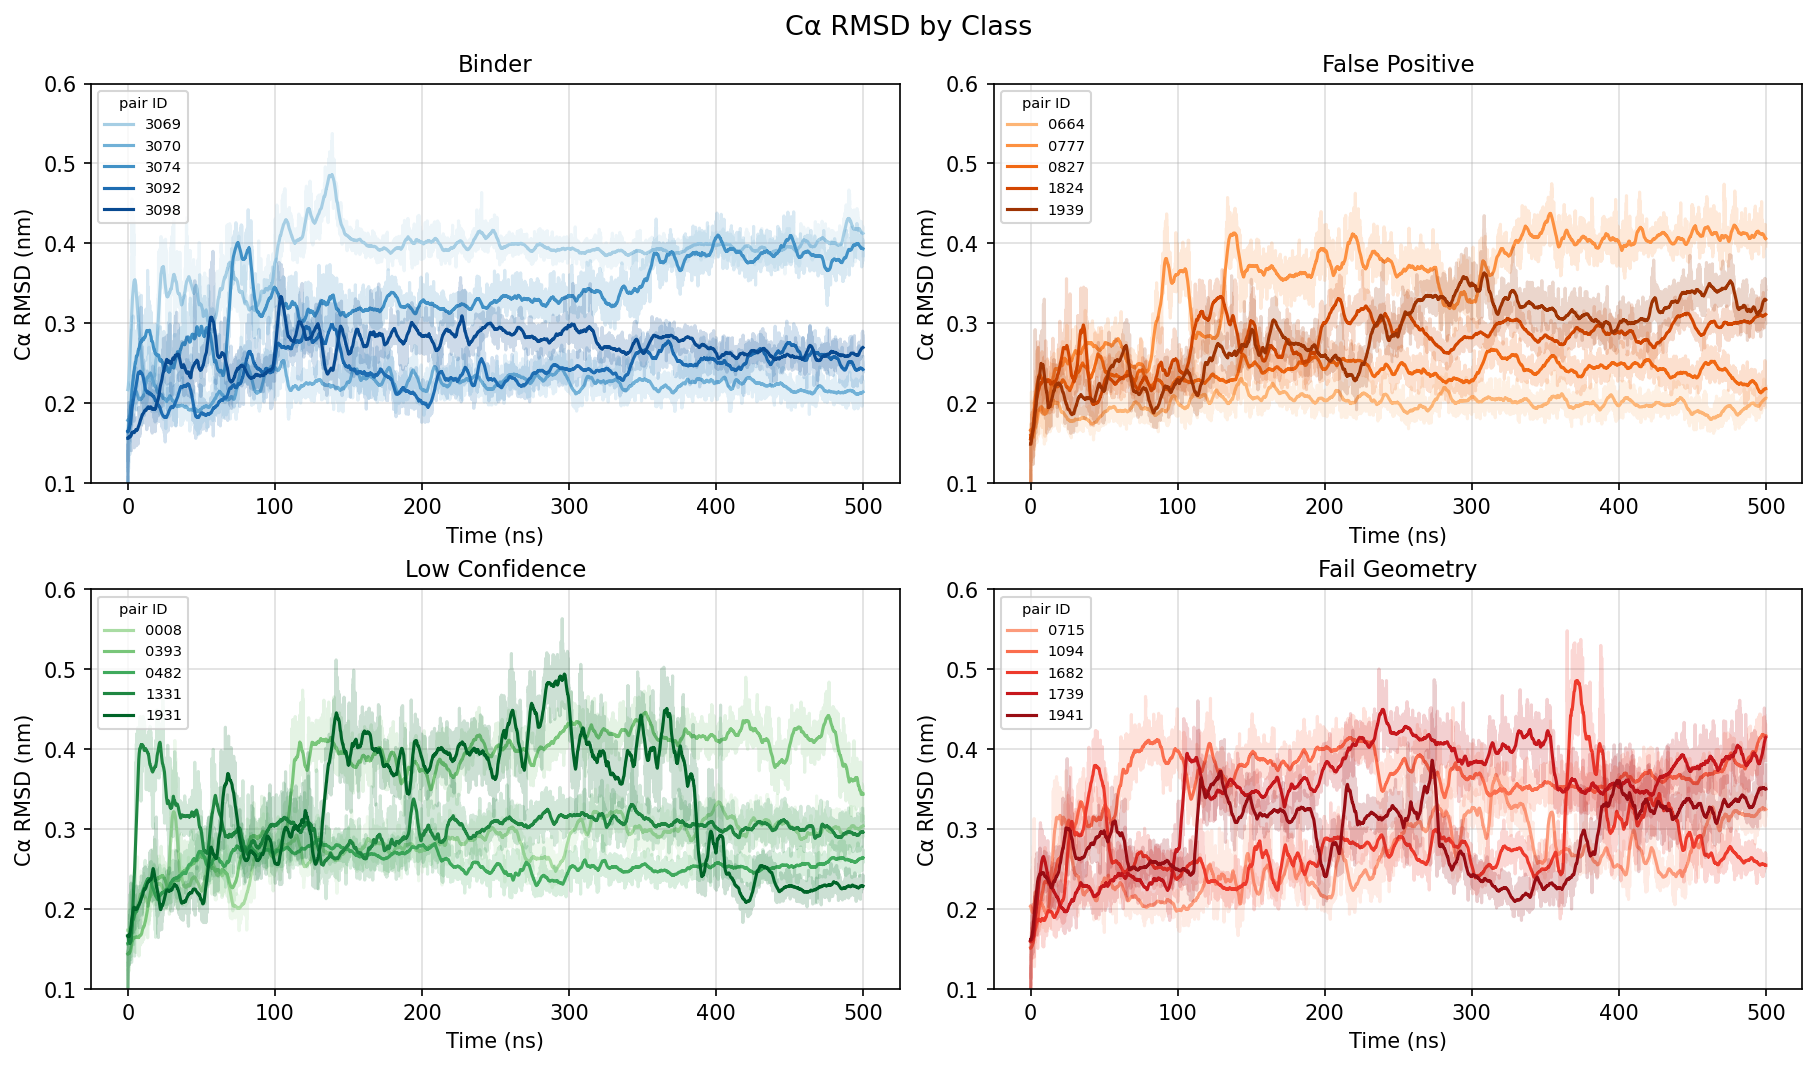

In [64]:
import matplotlib.colors as mcolors

base        = "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models"
prod_md_dir = "prod_md_0p9_cutoff_3dt_64x1_16PME_642dd"
rmsd_xvg    = "rmsd_CA.xvg"
OUTPUT_DIR = os.path.join(base, "open_gate_analysis")
os.makedirs(OUTPUT_DIR, exist_ok=True)

sequences = {
    "pair_3069_open_binder":    os.path.join(base, "binders",       "pair_3069_open_binder",    prod_md_dir, rmsd_xvg),
    "pair_3070_open_binder":    os.path.join(base, "binders",       "pair_3070_open_binder",    prod_md_dir, rmsd_xvg),
    "pair_3074_open_binder":    os.path.join(base, "binders",       "pair_3074_open_binder",    prod_md_dir, rmsd_xvg),
    "pair_3092_open_binder":    os.path.join(base, "binders",       "pair_3092_open_binder",    prod_md_dir, rmsd_xvg),
    "pair_3098_open_binder":    os.path.join(base, "binders",       "pair_3098_open_binder",    prod_md_dir, rmsd_xvg),
    "pair_0664_open_nb":        os.path.join(base, "nonbinders",    "pair_0664_open_nb",        prod_md_dir, rmsd_xvg),
    "pair_0777_open_nb":        os.path.join(base, "nonbinders",    "pair_0777_open_nb",        prod_md_dir, rmsd_xvg),
    "pair_0827_open_nb":        os.path.join(base, "nonbinders",    "pair_0827_open_nb",        prod_md_dir, rmsd_xvg),
    "pair_1824_open_nb":        os.path.join(base, "nonbinders",    "pair_1824_open_nb",        prod_md_dir, rmsd_xvg),
    "pair_1939_open_nb":        os.path.join(base, "nonbinders",    "pair_1939_open_nb",        prod_md_dir, rmsd_xvg),
    "pair_0008_open_low_pkt":   os.path.join(base, "neg_low_pkt",   "pair_0008_open_low_pkt",   prod_md_dir, rmsd_xvg),
    "pair_0393_open_low_pkt":   os.path.join(base, "neg_low_pkt",   "pair_0393_open_low_pkt",   prod_md_dir, rmsd_xvg),
    "pair_0482_open_low_pkt":   os.path.join(base, "neg_low_pkt",   "pair_0482_open_low_pkt",   prod_md_dir, rmsd_xvg),
    "pair_1331_open_low_pkt":   os.path.join(base, "neg_low_pkt",   "pair_1331_open_low_pkt",   prod_md_dir, rmsd_xvg),
    "pair_1931_open_low_pkt":   os.path.join(base, "neg_low_pkt",   "pair_1931_open_low_pkt",   prod_md_dir, rmsd_xvg),
    "pair_0715_open_fail_gate": os.path.join(base, "neg_fail_gate", "pair_0715_open_fail_gate", prod_md_dir, rmsd_xvg),
    "pair_1094_open_fail_gate": os.path.join(base, "neg_fail_gate", "pair_1094_open_fail_gate", prod_md_dir, rmsd_xvg),
    "pair_1682_open_fail_gate": os.path.join(base, "neg_fail_gate", "pair_1682_open_fail_gate", prod_md_dir, rmsd_xvg),
    "pair_1739_open_fail_gate": os.path.join(base, "neg_fail_gate", "pair_1739_open_fail_gate", prod_md_dir, rmsd_xvg),
    "pair_1941_open_fail_gate": os.path.join(base, "neg_fail_gate", "pair_1941_open_fail_gate", prod_md_dir, rmsd_xvg),
}

# --- class definitions ---
classes = {
    "binder":    {"title": "Binder",           "cmap": "Blues"},
    "nb":        {"title": "False Positive",   "cmap": "Oranges"},
    "low_pkt":   {"title": "Low Confidence",   "cmap": "Greens"},
    "fail_gate": {"title": "Fail Geometry",    "cmap": "Reds"},
}

def get_class(label):
    for key in classes:
        if label.endswith(key):
            return key
    return None

# Group sequences by class
grouped = {key: [] for key in classes}
for seq_label, xvg_path in sequences.items():
    cls = get_class(seq_label)
    if cls:
        grouped[cls].append((seq_label, xvg_path))

# --- plot ---
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 7), dpi=150, constrained_layout=True)
axs = axs.flatten()

for ax, (cls_key, cls_info) in zip(axs, classes.items()):
    members = grouped[cls_key]
    n       = len(members)
    cmap    = plt.get_cmap(cls_info["cmap"])
    # Sample shades from 0.35–0.90 to avoid near-white
    shades  = [cmap(0.35 + 0.55 * i / max(n - 1, 1)) for i in range(n)]

    for (seq_label, xvg_path), color in zip(members, shades):
        seq_id = seq_label.split("_")[1]
        x, y   = get_data(xvg_path)
        y_ma   = moving_average(y, window=130)
        ax.plot(x / 1000, y,    color=color, alpha=0.2)
        ax.plot(x / 1000, y_ma, color=color, alpha=1.0, label=seq_id)

    ax.set_title(cls_info["title"], fontsize=11)
    ax.set_xlabel("Time (ns)")
    ax.set_ylabel("Cα RMSD (nm)")
    ax.set_ylim(0.1,0.6)
    ax.legend(fontsize=7, title="pair ID", title_fontsize=7)
    ax.grid(True, alpha=0.4)

fig.suptitle("Cα RMSD by Class", fontsize=13)
rmsd_plot = os.path.join(OUTPUT_DIR, "open_gate_CA_rmsd.png")
#fig.savefig(rmsd_plot, dpi=150)
plt.show()

## comparative analysis

In [20]:
"""
gate_closure_timeseries.py

Analyzes gate-latch distance time series across sequences starting from open gate
conformations. Computes per-frame state assignments, smoothed traces, and
first passage times (FPT) to the closed state.

Assumes GROMACS gmx distance XVG output files exist per sequence:
    <base>/<runrel>/gate_latch_dist.xvg

Sequence directory naming supports both conventions:
    legacy: seq16_binder, seq7_nb, ...
    new:    pair_3069_binder, pair_0042_low_pkt, ...
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D

# ─────────────────────────────────────────────
# USER CONFIGURATION
# ─────────────────────────────────────────────

base          = "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models"
prod_md_dir   = "prod_md_0p9_cutoff_3dt_64x1_16PME_642dd"
gate_latch_xvg = "gate_latch_timeseries.xvg"

# Map sequence label -> full path to gate-latch XVG file
sequences = {
    "pair_3069_open":  os.path.join(base, "binders", "pair_3069_open_binder",  prod_md_dir, gate_latch_xvg),
    "pair_3070_open":  os.path.join(base, "binders", "pair_3070_open_binder",  prod_md_dir, gate_latch_xvg),
    "pair_3074_open":  os.path.join(base, "binders", "pair_3074_open_binder",  prod_md_dir, gate_latch_xvg),
    "pair_3092_open":  os.path.join(base, "binders", "pair_3092_open_binder",  prod_md_dir, gate_latch_xvg),
    "pair_3098_open":  os.path.join(base, "binders", "pair_3098_open_binder",  prod_md_dir, gate_latch_xvg),
    "pair_0664_open":  os.path.join(base, "nonbinders", "pair_0664_open_nb",       prod_md_dir, gate_latch_xvg),
    "pair_0777_open":  os.path.join(base, "nonbinders", "pair_0777_open_nb",       prod_md_dir, gate_latch_xvg),
    "pair_0827_open":  os.path.join(base, "nonbinders", "pair_0827_open_nb",       prod_md_dir, gate_latch_xvg),
    "pair_1824_open":  os.path.join(base, "nonbinders", "pair_1824_open_nb",       prod_md_dir, gate_latch_xvg),
    "pair_1939_open":  os.path.join(base, "nonbinders", "pair_1939_open_nb",       prod_md_dir, gate_latch_xvg),
    "pair_0008_open":  os.path.join(base, "neg_low_pkt", "pair_0008_open_low_pkt",  prod_md_dir, gate_latch_xvg),
    "pair_0393_open":  os.path.join(base, "neg_low_pkt", "pair_0393_open_low_pkt",  prod_md_dir, gate_latch_xvg),
    "pair_0482_open":  os.path.join(base, "neg_low_pkt", "pair_0482_open_low_pkt",  prod_md_dir, gate_latch_xvg),
    "pair_1331_open":  os.path.join(base, "neg_low_pkt", "pair_1331_open_low_pkt",  prod_md_dir, gate_latch_xvg),
    "pair_1931_open":  os.path.join(base, "neg_low_pkt", "pair_1931_open_low_pkt",  prod_md_dir, gate_latch_xvg),
    "pair_0715_open":  os.path.join(base, "neg_fail_gate", "pair_0715_open_fail_gate", prod_md_dir, gate_latch_xvg),
    "pair_1094_open":  os.path.join(base, "neg_fail_gate", "pair_1094_open_fail_gate", prod_md_dir, gate_latch_xvg),
    "pair_1682_open":  os.path.join(base, "neg_fail_gate", "pair_1682_open_fail_gate", prod_md_dir, gate_latch_xvg),
    "pair_1739_open":  os.path.join(base, "neg_fail_gate", "pair_1739_open_fail_gate", prod_md_dir, gate_latch_xvg),
    "pair_1941_open":  os.path.join(base, "neg_fail_gate", "pair_1941_open_fail_gate", prod_md_dir, gate_latch_xvg),
}

# Gate-latch distance thresholds (Angstroms)
CLOSED_THRESHOLD    = 9.5   # < this -> closed
OPEN_THRESHOLD      = 11.5  # > this -> open
# Between thresholds -> intermediate

# Smoothing window for rolling mean (number of frames)
# e.g., at 100 ps/frame, 100 frames = 10 ns
SMOOTH_WINDOW = 100

# Time step per frame in ns (adjust to match your trajectory output frequency)
DT_NS = 0.1   # e.g., 100 ps/frame

# Sequence type -> color mapping for plots
TYPE_COLORS = {
    "binder":    "#2166ac",
    "nb":        "#d73027",
    "low_pkt":   "#f4a582",
    "fail_gate": "#999999",
}

OUTPUT_DIR = os.path.join(base, "gate_closure_analysis")
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ─────────────────────────────────────────────
# HELPER FUNCTIONS
# ─────────────────────────────────────────────

def parse_xvg(filepath):
    """
    Parse a GROMACS .xvg file, skipping comment/metadata lines.
    Returns (time_array, distance_array) in the units present in the file.
    Distances are converted from nm to Angstroms (* 10).
    """
    times, dists = [], []
    with open(filepath, "r") as f:
        for line in f:
            if line.startswith("#") or line.startswith("@"):
                continue
            parts = line.split()
            if len(parts) >= 2:
                times.append(float(parts[0]))
                dists.append(float(parts[1]) * 10.0)  # nm -> Angstroms
    return np.array(times), np.array(dists)


def get_seq_type(xvg_path):
    """
    Extract sequence type (binder/nb/low_pkt/fail_gate) from the directory
    name in the full XVG path, e.g. '.../pair_3069_open_binder/...' -> 'binder'.
    """
    dir_name = os.path.basename(os.path.dirname(os.path.dirname(xvg_path)))
    for t in ["low_pkt", "fail_gate", "binder", "nb"]:   # longer tokens first
        if t in dir_name:
            return t
    return "unknown"


def get_display_label(seq_label):
    """
    Truncate to numeric ID for plot tick labels.
    'seq16_binder'     -> '16'
    'pair_3069_binder' -> '3069'
    """
    parts = seq_label.replace("pair_", "").replace("seq", "").split("_")
    return parts[0]


def assign_states(distances):
    """
    Assign per-frame conformational state.
    Returns integer array: 0=open, 1=intermediate, 2=closed
    """
    states = np.ones(len(distances), dtype=int)   # default: intermediate
    states[distances < CLOSED_THRESHOLD]  = 2     # closed
    states[distances > OPEN_THRESHOLD]    = 0     # open
    return states


def smooth_distances(distances, window=SMOOTH_WINDOW):
    """Rolling mean smoothing via convolution. Edges use 'same' mode."""
    kernel = np.ones(window) / window
    return np.convolve(distances, kernel, mode="same")


def first_passage_time(distances, threshold=CLOSED_THRESHOLD, dt_ns=DT_NS):
    """
    Time (ns) of first frame entering the closed state.
    Returns np.nan if the trajectory never reaches closed.
    """
    closed_frames = np.where(distances < threshold)[0]
    if len(closed_frames) == 0:
        return np.nan
    return closed_frames[0] * dt_ns


def state_occupancies(states):
    """
    Returns fractional occupancy of each state as a dict.
    """
    n = len(states)
    return {
        "open":         np.sum(states == 0) / n,
        "intermediate": np.sum(states == 1) / n,
        "closed":       np.sum(states == 2) / n,
    }


# ─────────────────────────────────────────────
# MAIN ANALYSIS LOOP
# ─────────────────────────────────────────────

records = []   # will become summary DataFrame
all_data = {}  # seq_label -> dict of arrays for plotting

print(f"{'Sequence':<30} {'FPT (ns)':>10} {'%Closed':>9} {'%Open':>8} {'%Inter':>9}")
print("-" * 70)

for seq_label, xvg_path in sequences.items():

    if not os.path.exists(xvg_path):
        print(f"  WARNING: {xvg_path} not found, skipping.")
        continue

    times, dists = parse_xvg(xvg_path)
    smoothed     = smooth_distances(dists)
    states       = assign_states(dists)
    fpt          = first_passage_time(dists)
    occ          = state_occupancies(states)
    seq_type     = get_seq_type(xvg_path)

    all_data[seq_label] = {
        "times":    times,
        "dists":    dists,
        "smoothed": smoothed,
        "states":   states,
        "seq_type": seq_type,
    }

    records.append({
        "sequence":          seq_label,
        "seq_type":          seq_type,
        "display_label":     get_display_label(seq_label),
        "fpt_ns":            fpt,
        "ever_closed":       not np.isnan(fpt),
        "occ_closed":        occ["closed"],
        "occ_open":          occ["open"],
        "occ_intermediate":  occ["intermediate"],
        "mean_dist_A":       np.mean(dists),
        "min_dist_A":        np.min(dists),
    })

    fpt_str = f"{fpt:.1f}" if not np.isnan(fpt) else "never"
    print(f"  {seq_label:<28} {fpt_str:>10} "
          f"{occ['closed']*100:>8.1f}% "
          f"{occ['open']*100:>7.1f}% "
          f"{occ['intermediate']*100:>8.1f}%")

summary_df = pd.DataFrame(records).set_index("sequence")
summary_csv = os.path.join(OUTPUT_DIR, "gate_closure_summary.csv")
summary_df.to_csv(summary_csv)
print(f"\nSummary saved to: {summary_csv}")


# ─────────────────────────────────────────────
# PLOT 1: Distance time series overlay (raw + smoothed)
# ─────────────────────────────────────────────

fig, axes = plt.subplots(
    len(all_data), 1,
    figsize=(12, 2.5 * len(all_data)),
    constrained_layout=True,
    sharex=True,
)
if len(all_data) == 1:
    axes = [axes]

for ax, (seq_label, data) in zip(axes, all_data.items()):
    times_ns = data["times"] * DT_NS if data["times"][0] < 100 else data["times"] / 1000.0
    # times_ns: adjust if your XVG time column is already in ns vs ps
    times_ns = np.arange(len(data["dists"])) * DT_NS  # safest: reindex from frame count

    color = TYPE_COLORS.get(data["seq_type"], "#444444")

    # Raw trace (faint)
    ax.plot(times_ns, data["dists"],
            color=color, alpha=0.25, linewidth=0.6, zorder=1)

    # Smoothed trace
    ax.plot(times_ns, data["smoothed"],
            color=color, alpha=0.9, linewidth=1.6, zorder=2,
            label=get_display_label(seq_label))

    # Threshold lines
    ax.axhline(CLOSED_THRESHOLD, color="green",  linestyle="--",
               linewidth=0.8, alpha=0.6, label="Closed threshold" if ax == axes[0] else "")
    ax.axhline(OPEN_THRESHOLD,   color="tomato", linestyle="--",
               linewidth=0.8, alpha=0.6, label="Open threshold" if ax == axes[0] else "")

    # Mark FPT
    fpt = summary_df.loc[seq_label, "fpt_ns"]
    if not np.isnan(fpt):
        ax.axvline(fpt, color="black", linestyle=":", linewidth=1.2, alpha=0.7)
        ax.text(fpt, ax.get_ylim()[1] if ax.get_ylim()[1] > 1 else OPEN_THRESHOLD + 1,
                f" FPT={fpt:.0f}ns", fontsize=7, va="top", color="black")

    ax.set_ylabel("Distance (Å)", fontsize=8)
    ax.set_title(f"{seq_label}  [{data['seq_type']}]", fontsize=9, loc="left", pad=2)
    ax.grid(True, alpha=0.4)
    ax.set_ylim(bottom=5)

axes[-1].set_xlabel("Time (ns)", fontsize=10)

# Global legend for thresholds
legend_elements = [
    Line2D([0], [0], color="green",  linestyle="--", label=f"Closed (<{CLOSED_THRESHOLD} Å)"),
    Line2D([0], [0], color="tomato", linestyle="--", label=f"Open (>{OPEN_THRESHOLD} Å)"),
    Line2D([0], [0], color="black",  linestyle=":",  label="FPT"),
]
fig.legend(handles=legend_elements, loc="upper right", fontsize=8, framealpha=0.85)
fig.suptitle("Gate–Latch Distance Time Series", fontsize=13, fontweight="bold")

ts_plot = os.path.join(OUTPUT_DIR, "gate_timeseries_overlay.png")
fig.savefig(ts_plot, dpi=150)
plt.close(fig)
print(f"Time series plot saved: {ts_plot}")


# ─────────────────────────────────────────────
# PLOT 2: FPT comparison across sequences
# ─────────────────────────────────────────────

# Sort by seq_type then FPT for readability
plot_df = summary_df.reset_index().sort_values(["seq_type", "fpt_ns"])

fig, ax = plt.subplots(figsize=(max(6, len(plot_df) * 0.7), 5), constrained_layout=True)

bar_colors = [TYPE_COLORS.get(t, "#444444") for t in plot_df["seq_type"]]
x_pos = np.arange(len(plot_df))

# Use max simulation time as a stand-in for "never closed" bars
max_time = max(len(d["dists"]) for d in all_data.values()) * DT_NS
fpt_vals = plot_df["fpt_ns"].fillna(max_time).values

bars = ax.bar(x_pos, fpt_vals, color=bar_colors, edgecolor="white",
              linewidth=0.8, alpha=0.85)

# Hatch "never closed" bars
for bar, fpt, label in zip(bars, plot_df["fpt_ns"], plot_df["sequence"]):
    if np.isnan(fpt):
        bar.set_hatch("///")
        bar.set_alpha(0.5)

ax.set_xticks(x_pos)
ax.set_xticklabels(plot_df["display_label"], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("First Passage Time (ns)", fontsize=11)
ax.set_xlabel("Sequence ID", fontsize=11)
ax.set_title("First Passage Time to Closed Gate State", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.4, axis="y")

# Legend for sequence types
legend_elements = [
    Line2D([0], [0], marker="s", color="w", markerfacecolor=c,
           markersize=10, label=t)
    for t, c in TYPE_COLORS.items()
]
legend_elements.append(
    Line2D([0], [0], marker="s", color="w", markerfacecolor="#aaaaaa",
           markersize=10, label="never closed (hatched)")
)
ax.legend(handles=legend_elements, fontsize=8, framealpha=0.85)

fpt_plot = os.path.join(OUTPUT_DIR, "gate_fpt_barplot.png")
fig.savefig(fpt_plot, dpi=150)
plt.close(fig)
print(f"FPT bar plot saved:     {fpt_plot}")


# ─────────────────────────────────────────────
# PLOT 3: State occupancy stacked bar
# ─────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(max(6, len(plot_df) * 0.7), 5), constrained_layout=True)

occ_closed = plot_df["occ_closed"].values * 100
occ_inter  = plot_df["occ_intermediate"].values * 100
occ_open   = plot_df["occ_open"].values * 100

ax.bar(x_pos, occ_closed, label="Closed",       color="#2166ac", edgecolor="white")
ax.bar(x_pos, occ_inter,  label="Intermediate", color="#f4a582",
       bottom=occ_closed, edgecolor="white")
ax.bar(x_pos, occ_open,   label="Open",         color="#d73027",
       bottom=occ_closed + occ_inter, edgecolor="white")

ax.set_xticks(x_pos)
ax.set_xticklabels(plot_df["display_label"], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Occupancy (%)", fontsize=11)
ax.set_xlabel("Sequence ID", fontsize=11)
ax.set_title("Gate Conformational State Occupancy", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.4, axis="y")
ax.legend(fontsize=9, framealpha=0.85)

occ_plot = os.path.join(OUTPUT_DIR, "gate_state_occupancy.png")
fig.savefig(occ_plot, dpi=150)
plt.close(fig)
print(f"Occupancy plot saved:   {occ_plot}")

print("\nDone. Summary DataFrame:")
print(summary_df[["seq_type", "fpt_ns", "ever_closed",
                   "occ_closed", "occ_open", "mean_dist_A"]].to_string())

Sequence                         FPT (ns)   %Closed    %Open    %Inter
----------------------------------------------------------------------
  pair_3069_open                    never      0.0%    99.7%      0.3%
  pair_3070_open                    never      0.0%    99.2%      0.8%
  pair_3074_open                    never      0.0%    99.1%      0.9%
  pair_3092_open                    never      0.0%    99.0%      1.0%
  pair_3098_open                    never      0.0%    99.7%      0.3%
  pair_0664_open                    330.3      0.0%    99.0%      0.9%
  pair_0777_open                    never      0.0%   100.0%      0.0%
  pair_0827_open                     15.7      3.6%    93.4%      3.0%
  pair_1824_open                    never      0.0%   100.0%      0.0%
  pair_1939_open                    133.3      3.7%    75.3%     21.0%
  pair_0008_open                    never      0.0%   100.0%      0.0%
  pair_0393_open                      9.7      1.4%    79.5%     19.1%
  pair

## RMSD ref closed structure

In [46]:
"""
gate_rmsd_timeseries.py

For each open-starting trajectory, computes the gate Cα RMSD over time
relative to that sequence's own per-sequence closed reference structure
(medoid_system.pdb from the closed-gate run).

First passage time (FPT) is defined as the first frame where gate RMSD
drops below RMSD_THRESHOLD, indicating the gate has adopted the closed
conformation.

Path conventions
----------------
Open trajectory:    {base}/{type_subdir}/{seq_dir}/{prod_md_dir}/prod_md_500ns.xtc
Open topology:      {base}/{type_subdir}/{seq_dir}/{prod_md_dir}/medoid_system.pdb
Closed reference:   {base}/{type_subdir}/{seq_dir_no_open}/{prod_md_dir}/medoid_system.pdb

  type_subdir is derived from sequence type:
    binder    -> binders
    nb        -> nonbinders
    low_pkt   -> neg_low_pkt
    fail_gate -> neg_fail_gate

  e.g. seq_dir         = "pair_3069_open_binder"
       seq_dir_no_open  = "pair_3069_binder"
       type_subdir       = "binders"
"""

import os
import numpy as np
import pandas as pd
import mdtraj as md
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ─────────────────────────────────────────────
# USER CONFIGURATION
# ─────────────────────────────────────────────

base         = "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models"
prod_md_dir  = "prod_md_0p9_cutoff_3dt_64x1_16PME_642dd"

# Gate residues: ISGLPA (ILE SER GLY LEU PRO ALA) within resSeq 80-100
# Using residue names + window avoids index shifting across different topologies
GATE_RESNAMES = ["ILE", "SER", "GLY", "LEU", "PRO", "ALA"]
GATE_RESSEQ_WINDOW = (80, 100)

# RMSD threshold for "closed" state (Angstroms)
RMSD_THRESHOLD = 2.0    # gate is considered closed if RMSD < this value

# Time step per frame in ns
DT_NS = 0.1             # adjust to match your trajectory output frequency

# Smoothing window (frames)
SMOOTH_WINDOW = 100

# Sequence type -> color
TYPE_COLORS = {
    "binder":    "#2166ac",
    "nb":        "#d73027",
    "low_pkt":   "#f4a582",
    "fail_gate": "#999999",
}

# Sequence type -> category subdirectory name on disk
TYPE_SUBDIRS = {
    "binder":    "binders",
    "nb":        "nonbinders",
    "low_pkt":   "neg_low_pkt",
    "fail_gate": "neg_fail_gate",
}

# open-gate sequence directory names (the _open_ directories)
open_seq_dirs = [
    "pair_3069_open_binder",
    "pair_3070_open_binder",
    "pair_3074_open_binder",
    "pair_3092_open_binder",
    "pair_3098_open_binder",
    "pair_0664_open_nb",
    # "pair_0777_open_nb",
    # "pair_0827_open_nb",
    # "pair_1824_open_nb",
    # "pair_1939_open_nb",
    # "pair_0008_open_low_pkt",
    # "pair_0393_open_low_pkt",
    # "pair_0482_open_low_pkt",
    # "pair_1331_open_low_pkt",
    # "pair_1931_open_low_pkt",
    # "pair_0715_open_fail_gate",
    # "pair_1094_open_fail_gate",
    # "pair_1682_open_fail_gate",
    # "pair_1739_open_fail_gate",
    # "pair_1941_open_fail_gate",
]

OUTPUT_DIR = os.path.join(base, "gate_rmsd_analysis")
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ─────────────────────────────────────────────
# HELPER FUNCTIONS
# ─────────────────────────────────────────────

def get_seq_type(seq_dir):
    """Extract sequence type from directory name."""
    for t in ["low_pkt", "fail_gate", "binder", "nb"]:
        if t in seq_dir:
            return t
    return "unknown"


def get_display_label(seq_dir):
    """
    Truncate to numeric ID for plot tick labels.
    'pair_3069_open_binder' -> '3069'
    """
    parts = seq_dir.replace("pair_", "").split("_")
    return parts[0]


def get_closed_ref_dir(open_seq_dir):
    """
    Derive the closed reference directory by removing '_open' from the
    open directory name.
    'pair_3069_open_binder' -> 'pair_3069_binder'
    'pair_0664_open_nb'     -> 'pair_0664_nb'
    """
    return open_seq_dir.replace("_open_", "_")


def get_common_ca_indices(traj_top, ref_top, resseq_offset=0,
                          gate_start_ref=84, gate_end_ref=89):
    """
    Find Cα atom indices for structurally equivalent residues across two
    topologies, handling a resSeq offset caused by an insertion near the gate.

    Splits into two regions:
      Pre-insertion  (ref resSeq < gate_start_ref): direct match, no offset
      Post-gate      (ref resSeq > gate_end_ref):   match with offset
                                                    (traj_resSeq - offset == ref_resSeq)
      Gate region    (gate_start_ref to gate_end_ref): excluded

    Parameters
    ----------
    resseq_offset  : traj.resSeq - ref.resSeq for equivalent residues
                     at the gate (computed from gate anchor).
    gate_start_ref : first gate resSeq in ref numbering.
    gate_end_ref   : last gate resSeq in ref numbering.
    """
    def resseq_ca_map(topology):
        mapping = {}
        for res in topology.residues:
            ca = [a.index for a in res.atoms if a.name == "CA"]
            if ca:
                mapping[res.resSeq] = ca[0]
        return mapping

    traj_map = resseq_ca_map(traj_top)
    ref_map  = resseq_ca_map(ref_top)

    pairs = []
    for ref_resseq, ref_ca in ref_map.items():
        # Skip gate region
        if gate_start_ref <= ref_resseq <= gate_end_ref:
            continue
        if ref_resseq < gate_start_ref:
            # Pre-insertion: resSeq is the same in both topologies
            traj_resseq = ref_resseq
        else:
            # Post-gate: traj resSeq is shifted by the insertion offset
            traj_resseq = ref_resseq + resseq_offset
        if traj_resseq in traj_map:
            pairs.append((traj_map[traj_resseq], ref_ca))

    pairs.sort()
    traj_idx = np.array([p[0] for p in pairs])
    ref_idx  = np.array([p[1] for p in pairs])

    return traj_idx, ref_idx


def find_gate_atoms(topology, pattern=("ILE", "SER", "GLY", "LEU", "PRO", "ALA"),
                    resseq_window=(80, 100)):
    """
    Find Cα atom indices for a consecutive residue pattern within a resSeq window.
    Scans residues in order and returns indices of the first matching run.

    Parameters
    ----------
    topology      : mdtraj.Topology
    pattern       : tuple of three-letter residue names to match in order
    resseq_window : (min_resSeq, max_resSeq) inclusive search window

    Returns
    -------
    np.ndarray of Cα atom indices, or None if pattern not found
    """
    # Collect (resSeq, resname, CA_atom_index) for residues in the window
    window_residues = []
    for res in topology.residues:
        if resseq_window[0] <= res.resSeq <= resseq_window[1]:
            ca_atoms = [a.index for a in res.atoms if a.name == "CA"]
            if ca_atoms:
                window_residues.append((res.resSeq, res.name, ca_atoms[0]))

    # Slide over window residues looking for the consecutive pattern
    n = len(pattern)
    for i in range(len(window_residues) - n + 1):
        chunk = window_residues[i:i + n]
        if tuple(r[1] for r in chunk) == pattern:
            return np.array([r[2] for r in chunk])

    return None


def smooth(arr, window=SMOOTH_WINDOW):
    """Rolling mean via convolution."""
    kernel = np.ones(window) / window
    return np.convolve(arr, kernel, mode="same")


def first_passage_time(rmsd_A, threshold=RMSD_THRESHOLD, dt_ns=DT_NS):
    """
    First frame (converted to ns) where gate RMSD < threshold.
    Returns np.nan if never reached.
    """
    frames = np.where(rmsd_A < threshold)[0]
    if len(frames) == 0:
        return np.nan
    return frames[0] * dt_ns


def compute_gate_rmsd(open_seq_dir):
    """
    Load open trajectory and closed reference, align on all Cα,
    then compute RMSD of gate Cα residues only.

    Returns rmsd_A (np.ndarray, Angstroms) or None on error.
    """
    seq_type    = get_seq_type(open_seq_dir)
    type_subdir = TYPE_SUBDIRS.get(seq_type, "")

    xtc_path = os.path.join(base, type_subdir, open_seq_dir,                     prod_md_dir, "prod_md_500ns_fit.xtc")
    top_path = os.path.join(base, type_subdir, open_seq_dir,                     prod_md_dir, "prod_md_500ns.gro")
    ref_path = os.path.join(base, type_subdir, get_closed_ref_dir(open_seq_dir), prod_md_dir, "medoid_PL.pdb")

    for label, path in [("trajectory", xtc_path), ("topology", top_path), ("reference", ref_path)]:
        if not os.path.exists(path):
            print(f"  WARNING [{open_seq_dir}]: {label} not found:\n    {path}")
            return None

    # Load reference and trajectory
    ref  = md.load(ref_path)
    traj = md.load(xtc_path, top=top_path)
    traj.make_molecules_whole()   # fix PBC wrapping artifacts before RMSD

    # Find gate Cα indices by matching the consecutive ISGLPA pattern
    # within resSeq 80-100 in both trajectory and reference topologies
    gate_atoms = find_gate_atoms(traj.topology)
    ref_gate   = find_gate_atoms(ref.topology)

    if gate_atoms is None:
        print(f"  WARNING [{open_seq_dir}]: ISGLPA pattern not found in trajectory topology.")
        return None
    if ref_gate is None:
        print(f"  WARNING [{open_seq_dir}]: ISGLPA pattern not found in reference topology.")
        return None

    # Compute resSeq offset between the two topologies using the gate
    # anchor — the first gate residue is structurally equivalent in both
    traj_gate_resseq = traj.topology.atom(gate_atoms[0]).residue.resSeq
    ref_gate_resseq  = ref.topology.atom(ref_gate[0]).residue.resSeq
    resseq_offset    = traj_gate_resseq - ref_gate_resseq  # e.g. 87 - 84 = 3

    # Find conserved Cα residues using offset-corrected resSeq matching,
    # excluding the gate window (in ref numbering) so alignment is
    # independent of the region being measured
    align_traj, align_ref = get_common_ca_indices(
        traj.topology, ref.topology,
        resseq_offset=resseq_offset,
        gate_start_ref=ref_gate_resseq,
        gate_end_ref=ref.topology.atom(ref_gate[-1]).residue.resSeq,
    )

    if len(align_traj) == 0:
        print(f"  WARNING [{open_seq_dir}]: no common residues found for alignment.")
        return None

    print(f"  [{open_seq_dir}]: {len(gate_atoms)} gate Cα atoms | "
          f"{len(align_traj)} conserved residues used for alignment.")

    # Align on conserved core (excludes gate) to remove rigid-body motion
    traj.superpose(ref, atom_indices=align_traj, ref_atom_indices=align_ref)

    # Compute gate RMSD manually from post-superposition coordinates.
    # md.rmsd() cannot be used here — it always internally re-superposes
    # on the atom_indices you pass, which would re-fit on the gate atoms
    # themselves and artificially minimise the RMSD.
    traj_gate_xyz = traj.xyz[:, gate_atoms, :]      # (n_frames, 6, 3) nm
    ref_gate_xyz  = ref.xyz[0, ref_gate, :]          # (6, 3) nm

    diff   = traj_gate_xyz - ref_gate_xyz[np.newaxis]  # (n_frames, 6, 3)
    rmsd_A = np.sqrt((diff**2).sum(axis=(1, 2)) / len(gate_atoms)) * 10.0  # nm -> Å

    return rmsd_A

In [47]:
# ─────────────────────────────────────────────
# MAIN ANALYSIS LOOP
# ─────────────────────────────────────────────

records  = []
all_data = {}

print(f"{'Sequence':<35} {'FPT (ns)':>10} {'Min RMSD (Å)':>14} {'Mean RMSD (Å)':>14}")
print("-" * 78)

for seq_dir in open_seq_dirs:
    seq_type = get_seq_type(seq_dir)
    label    = get_display_label(seq_dir)

    rmsd_A = compute_gate_rmsd(seq_dir)
    if rmsd_A is None:
        continue

    rmsd_smooth = smooth(rmsd_A)
    fpt         = first_passage_time(rmsd_A)

    all_data[seq_dir] = {
        "rmsd":     rmsd_A,
        "smoothed": rmsd_smooth,
        "seq_type": seq_type,
    }

    records.append({
        "sequence":      seq_dir,
        "seq_type":      seq_type,
        "display_label": label,
        "fpt_ns":        fpt,
        "ever_closed":   not np.isnan(fpt),
        "min_rmsd_A":    np.min(rmsd_A),
        "mean_rmsd_A":   np.mean(rmsd_A),
        "occ_closed":    np.mean(rmsd_A < RMSD_THRESHOLD),
    })

    fpt_str = f"{fpt:.1f}" if not np.isnan(fpt) else "never"
    print(f"  {seq_dir:<33} {fpt_str:>10} "
          f"{np.min(rmsd_A):>13.2f} "
          f"{np.mean(rmsd_A):>13.2f}")

summary_df = pd.DataFrame(records).set_index("sequence")
csv_path   = os.path.join(OUTPUT_DIR, "gate_rmsd_summary.csv")
summary_df.to_csv(csv_path)
print(f"\nSummary saved: {csv_path}")


# ─────────────────────────────────────────────
# PLOT 1: RMSD time series — one panel per sequence
# ─────────────────────────────────────────────

n = len(all_data)
fig, axes = plt.subplots(n, 1, figsize=(12, 2.5 * n),
                         constrained_layout=True, sharex=True)
if n == 1:
    axes = [axes]

for ax, (seq_dir, data) in zip(axes, all_data.items()):
    times_ns = np.arange(len(data["rmsd"])) * DT_NS
    color    = TYPE_COLORS.get(data["seq_type"], "#444444")

    # Raw (faint) + smoothed (bold)
    ax.plot(times_ns, data["rmsd"],     color=color, alpha=0.2, linewidth=0.6)
    ax.plot(times_ns, data["smoothed"], color=color, alpha=0.9, linewidth=1.6)

    # Closed threshold line
    ax.axhline(RMSD_THRESHOLD, color="green", linestyle="--",
               linewidth=0.9, alpha=0.7)

    # Mark FPT
    fpt = summary_df.loc[seq_dir, "fpt_ns"]
    if not np.isnan(fpt):
        ax.axvline(fpt, color="black", linestyle=":", linewidth=1.2, alpha=0.8)
        ax.text(fpt + times_ns[-1] * 0.01, RMSD_THRESHOLD + 0.1,
                f"FPT={fpt:.0f}ns", fontsize=7, va="bottom", color="black")

    ax.set_ylabel("Gate RMSD (Å)", fontsize=8)
    ax.set_title(f"{seq_dir}  [{data['seq_type']}]", fontsize=9, loc="left", pad=2)
    ax.grid(True, alpha=0.4)
    ax.set_ylim(bottom=0)

axes[-1].set_xlabel("Time (ns)", fontsize=10)

legend_elements = [
    Line2D([0], [0], color="green", linestyle="--",
           label=f"Closed threshold ({RMSD_THRESHOLD} Å)"),
    Line2D([0], [0], color="black", linestyle=":", label="FPT"),
]
fig.legend(handles=legend_elements, loc="upper right", fontsize=8, framealpha=0.85)
fig.suptitle("Gate Cα RMSD to Closed Reference", fontsize=13, fontweight="bold")

ts_plot = os.path.join(OUTPUT_DIR, "gate_rmsd_timeseries.png")
fig.savefig(ts_plot, dpi=150)
plt.close(fig)
print(f"Time series plot saved: {ts_plot}")


# ─────────────────────────────────────────────
# PLOT 2: FPT bar plot grouped by sequence type
# ─────────────────────────────────────────────

plot_df   = summary_df.reset_index().sort_values(["seq_type", "fpt_ns"])
x_pos     = np.arange(len(plot_df))
max_time  = max(len(d["rmsd"]) for d in all_data.values()) * DT_NS
fpt_vals  = plot_df["fpt_ns"].fillna(max_time).values
bar_colors = [TYPE_COLORS.get(t, "#444444") for t in plot_df["seq_type"]]

fig, ax = plt.subplots(figsize=(max(6, len(plot_df) * 0.7), 5),
                       constrained_layout=True)
bars = ax.bar(x_pos, fpt_vals, color=bar_colors,
              edgecolor="white", linewidth=0.8, alpha=0.85)

# Hatch sequences that never closed
for bar, fpt in zip(bars, plot_df["fpt_ns"]):
    if np.isnan(fpt):
        bar.set_hatch("///")
        bar.set_alpha(0.45)

ax.set_xticks(x_pos)
ax.set_xticklabels(plot_df["display_label"], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("First Passage Time (ns)", fontsize=11)
ax.set_xlabel("Sequence ID", fontsize=11)
ax.set_title("FPT to Closed Gate (Gate Cα RMSD < "
             f"{RMSD_THRESHOLD} Å vs. Closed Reference)", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.4, axis="y")

legend_elements = [
    Line2D([0], [0], marker="s", color="w", markerfacecolor=c,
           markersize=10, label=t)
    for t, c in TYPE_COLORS.items()
] + [
    Line2D([0], [0], marker="s", color="w", markerfacecolor="#aaaaaa",
           markersize=10, label="never closed (hatched)")
]
ax.legend(handles=legend_elements, fontsize=8, framealpha=0.85)

fpt_plot = os.path.join(OUTPUT_DIR, "gate_rmsd_fpt_barplot.png")
fig.savefig(fpt_plot, dpi=150)
plt.close(fig)
print(f"FPT bar plot saved:     {fpt_plot}")


# ─────────────────────────────────────────────
# PLOT 3: Min RMSD strip plot (how close did each sequence get?)
# ─────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(max(6, len(plot_df) * 0.7), 5),
                       constrained_layout=True)

for i, (_, row) in enumerate(plot_df.iterrows()):
    color = TYPE_COLORS.get(row["seq_type"], "#444444")
    ax.scatter(i, row["min_rmsd_A"], color=color, s=70, zorder=3)

ax.axhline(RMSD_THRESHOLD, color="green", linestyle="--",
           linewidth=1.0, alpha=0.7, label=f"Closed threshold ({RMSD_THRESHOLD} Å)")
ax.set_xticks(np.arange(len(plot_df)))
ax.set_xticklabels(plot_df["display_label"], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Minimum Gate RMSD (Å)", fontsize=11)
ax.set_xlabel("Sequence ID", fontsize=11)
ax.set_title("Closest Approach to Closed Conformation per Sequence",
             fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.4)

legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=c,
           markersize=9, label=t)
    for t, c in TYPE_COLORS.items()
] + [ax.get_lines()[0]]
ax.legend(handles=legend_elements, fontsize=8, framealpha=0.85)

min_plot = os.path.join(OUTPUT_DIR, "gate_rmsd_min_approach.png")
fig.savefig(min_plot, dpi=150)
plt.close(fig)
print(f"Min RMSD plot saved:    {min_plot}")

print("\nDone. Summary:")
print(summary_df[["seq_type", "fpt_ns", "ever_closed",
                   "min_rmsd_A", "mean_rmsd_A", "occ_closed"]].to_string())

Sequence                              FPT (ns)   Min RMSD (Å)  Mean RMSD (Å)
------------------------------------------------------------------------------
  [pair_3069_open_binder]: 6 gate Cα atoms | 175 conserved residues used for alignment.
  pair_3069_open_binder                  never          3.72          6.23
  [pair_3070_open_binder]: 6 gate Cα atoms | 175 conserved residues used for alignment.
  pair_3070_open_binder                  never          2.08          5.58
  [pair_3074_open_binder]: 6 gate Cα atoms | 175 conserved residues used for alignment.
  pair_3074_open_binder                  never          2.41          7.71
  [pair_3092_open_binder]: 6 gate Cα atoms | 175 conserved residues used for alignment.
  pair_3092_open_binder                  never          3.02          7.60
  [pair_3098_open_binder]: 6 gate Cα atoms | 175 conserved residues used for alignment.
  pair_3098_open_binder                  never          2.78          6.70


OSError: Malformed XTC file. Number of atoms <= 0. Are you sure this is a valid GROMACS xtc file?

In [27]:
import mdtraj as md
import numpy as np

base        = "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models"
prod_md_dir = "prod_md_0p9_cutoff_3dt_64x1_16PME_642dd"

xtc_path = os.path.join(base, "binders", "pair_3069_open_binder", prod_md_dir, "prod_md_500ns_fit.xtc")
top_path = os.path.join(base, "binders", "pair_3069_open_binder", prod_md_dir, "prod_md_500ns.gro")
ref_path = os.path.join(base, "binders", "pair_3069_binder",      prod_md_dir, "medoid_PL.pdb")

ref  = md.load(ref_path)
traj = md.load(xtc_path, top=top_path)
traj.make_molecules_whole()

gate_atoms = find_gate_atoms(traj.topology)
ref_gate   = find_gate_atoms(ref.topology)

print("Gate residues (traj):")
for idx in gate_atoms:
    atom = traj.topology.atom(idx)
    print(f"  atom {idx:5d}  resSeq {atom.residue.resSeq:4d}  resname {atom.residue.name}")

print("\nGate residues (ref):")
for idx in ref_gate:
    atom = ref.topology.atom(idx)
    print(f"  atom {idx:5d}  resSeq {atom.residue.resSeq:4d}  resname {atom.residue.name}")

# Compute offset from gate anchor
traj_gate_resseq = traj.topology.atom(gate_atoms[0]).residue.resSeq
ref_gate_resseq  = ref.topology.atom(ref_gate[0]).residue.resSeq
resseq_offset    = traj_gate_resseq - ref_gate_resseq
print(f"\nresSeq offset: {resseq_offset} (traj {traj_gate_resseq} → ref {ref_gate_resseq})")

gate_start_ref = ref_gate_resseq
gate_end_ref   = ref.topology.atom(ref_gate[-1]).residue.resSeq

align_traj, align_ref = get_common_ca_indices(
    traj.topology, ref.topology,
    resseq_offset=resseq_offset,
    gate_start_ref=gate_start_ref,
    gate_end_ref=gate_end_ref,
)
print(f"Alignment residues: {len(align_traj)}")
print("First 3 alignment pairs (traj resSeq -> ref resSeq):")
for ti, ri in zip(align_traj[:3], align_ref[:3]):
    t_res = traj.topology.atom(ti).residue
    r_res = ref.topology.atom(ri).residue
    print(f"  traj {t_res.resSeq} {t_res.name}  ->  ref {r_res.resSeq} {r_res.name}")
print("Last 3 alignment pairs:")
for ti, ri in zip(align_traj[-3:], align_ref[-3:]):
    t_res = traj.topology.atom(ti).residue
    r_res = ref.topology.atom(ri).residue
    print(f"  traj {t_res.resSeq} {t_res.name}  ->  ref {r_res.resSeq} {r_res.name}")

# RMSD before superpose
rmsd_before = md.rmsd(traj, ref, atom_indices=gate_atoms, ref_atom_indices=ref_gate) * 10.0
print(f"\nRMSD before superpose — frame 0: {rmsd_before[0]:.2f} Å, mean: {rmsd_before.mean():.2f} Å")

# RMSD after superpose on offset-corrected conserved core
traj.superpose(ref, atom_indices=align_traj, ref_atom_indices=align_ref)
traj_gate_xyz = traj.xyz[:, gate_atoms, :]
ref_gate_xyz  = ref.xyz[0, ref_gate, :]
diff          = traj_gate_xyz - ref_gate_xyz[np.newaxis]
rmsd_after    = np.sqrt((diff**2).sum(axis=(1, 2)) / len(gate_atoms)) * 10.0
print(f"RMSD after superpose  — frame 0: {rmsd_after[0]:.2f} Å, mean: {rmsd_after.mean():.2f} Å")

Gate residues (traj):
  atom  1358  resSeq   87  resname ILE
  atom  1377  resSeq   88  resname SER
  atom  1388  resSeq   89  resname GLY
  atom  1395  resSeq   90  resname LEU
  atom  1414  resSeq   91  resname PRO
  atom  1428  resSeq   92  resname ALA

Gate residues (ref):
  atom  1321  resSeq   84  resname ILE
  atom  1340  resSeq   85  resname SER
  atom  1351  resSeq   86  resname GLY
  atom  1358  resSeq   87  resname LEU
  atom  1376  resSeq   88  resname PRO
  atom  1391  resSeq   89  resname ALA

resSeq offset: 3 (traj 87 → ref 84)
Alignment residues: 175
First 3 alignment pairs (traj resSeq -> ref resSeq):
  traj 1 MET  ->  ref 1 MET
  traj 2 ALA  ->  ref 2 ALA
  traj 3 SER  ->  ref 3 SER
Last 3 alignment pairs:
  traj 182 VAL  ->  ref 179 ALA
  traj 183 ALA  ->  ref 180 ARG
  traj 184 GLU  ->  ref 181 ASN

RMSD before superpose — frame 0: 1.94 Å, mean: 0.60 Å
RMSD after superpose  — frame 0: 7.20 Å, mean: 6.23 Å


In [28]:
print(f"Min RMSD: {rmsd_after.min():.2f} Å at frame {rmsd_after.argmin()}")
print(f"Max RMSD: {rmsd_after.max():.2f} Å at frame {rmsd_after.argmax()}")
print(f"Frames below {RMSD_THRESHOLD} Å threshold: {np.sum(rmsd_after < RMSD_THRESHOLD)}")

Min RMSD: 3.72 Å at frame 1827
Max RMSD: 9.75 Å at frame 148
Frames below 2.0 Å threshold: 0


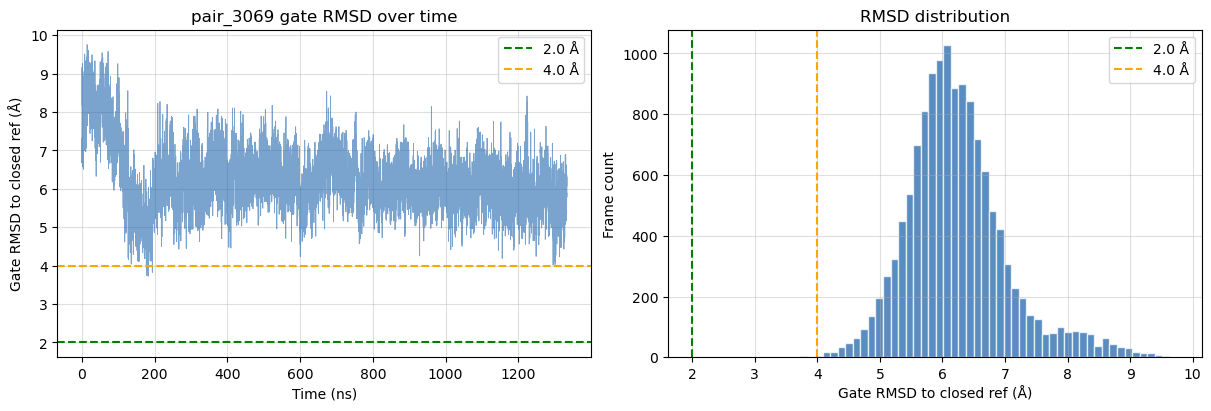

In [29]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

# Time series
times_ns = np.arange(len(rmsd_after)) * DT_NS
axes[0].plot(times_ns, rmsd_after, color="#2166ac", alpha=0.6, linewidth=0.6)
axes[0].axhline(2.0, color="green",  linestyle="--", label="2.0 Å")
axes[0].axhline(4.0, color="orange", linestyle="--", label="4.0 Å")
axes[0].set_xlabel("Time (ns)")
axes[0].set_ylabel("Gate RMSD to closed ref (Å)")
axes[0].set_title("pair_3069 gate RMSD over time")
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# Histogram
axes[1].hist(rmsd_after, bins=50, color="#2166ac", alpha=0.75, edgecolor="white")
axes[1].axvline(2.0, color="green",  linestyle="--", label="2.0 Å")
axes[1].axvline(4.0, color="orange", linestyle="--", label="4.0 Å")
axes[1].set_xlabel("Gate RMSD to closed ref (Å)")
axes[1].set_ylabel("Frame count")
axes[1].set_title("RMSD distribution")
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.savefig("pair_3069_rmsd_debug.png", dpi=150)
plt.show()